# MCMC one parameter

In [1]:
import pymc3 as pm
import numpy as np
import theano.tensor as tt
import matplotlib.pyplot as plt
from ann_functions import import_data, normalization
from keras.models import load_model
from keras.initializers import glorot_uniform
import keras.backend as K
from keras.utils import custom_object_scope
import tensorflow as tf
import keras
import math

WARN: Could not locate executable g77
WARN: Could not locate executable f77
WARN: Could not locate executable ifort
WARN: Could not locate executable ifl
WARN: Could not locate executable f90
WARN: Could not locate executable DF
WARN: Could not locate executable efl
WARN: Could not locate executable gfortran
WARN: Could not locate executable f95
WARN: Could not locate executable g95
WARN: Could not locate executable efort
WARN: Could not locate executable efc
WARN: Could not locate executable flang
WARN: don't know how to compile Fortran code on platform 'nt'


WARNING (theano.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (theano.configdefaults): g++ not detected ! Theano will be unable to execute optimized C-implementations (for both CPU and GPU) and will default to Python implementations. Performance will be severely degraded. To remove this warning, set Theano flags cxx to an empty string.
WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data introduction

In [3]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
U_HF_test = U_HF_test[:, -1, 44,44]

permutation = np.random.permutation(len(U_HF_test))
reaction_HF_test=normalization(reaction_HF_test)[permutation]
U_HF_test=normalization(U_HF_test)[permutation]


# personalized activation function
def custom_activation(x):
    
    return x + K.square(K.sin(x))

custom_objects = {'custom_activation': custom_activation }#, 'glorot_uniform': glorot_uniform()}

# Carica il modello utilizzando custom_objects
with custom_object_scope(custom_objects):

    keras_model1 = load_model("modelLF.h5")
    keras_model2 = load_model("modelLin.h5")
    keras_model3 = load_model("finalModel.h5")


def keras_predict(x):
    out1=keras_model1.predict(x)
    in2 = np.hstack((x, out1))
    out2=keras_model2.predict(in2)
    in3 = np.hstack((in2, out2))
    approx_model_output=keras_model3.predict(in3)
    
    return approx_model_output


[[0.26530612]]
1/1 [==============================] - 0s 18ms/step


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\deprecat\classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: divide by zero encountered in log
  variables = ufunc(*ufunc_args, **ufunc_kwargs)
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\theano\tensor\elemwise.py:826: RuntimeWarning: invalid value encountered in multiply
  variables = ufunc(*ufunc_args, **ufunc_kwargs)
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, mu]


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 33 seconds.
There were 122 divergences after tuning. Increase `target_accept` or reparameterize.
There were 301 divergences after tuning. Increase `target_accept` or reparameterize.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_32420\1860072423.py:7

       mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu     0.49  0.3   -0.08     1.06       0.01     0.00    2053.0    2146.0   
sigma  0.30  0.4    0.01     1.08       0.01     0.01    2115.0    2135.0   

       r_hat  
mu       1.0  
sigma    1.0  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.
Got error No model on context stack. trying to find log_likelihood in translation.
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


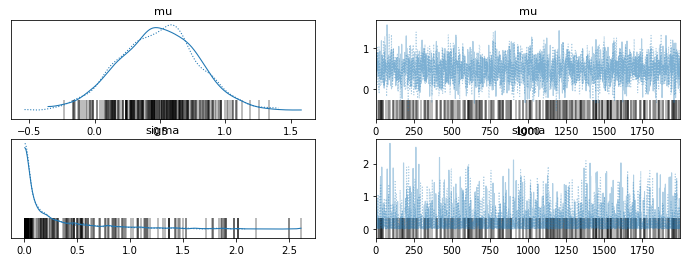

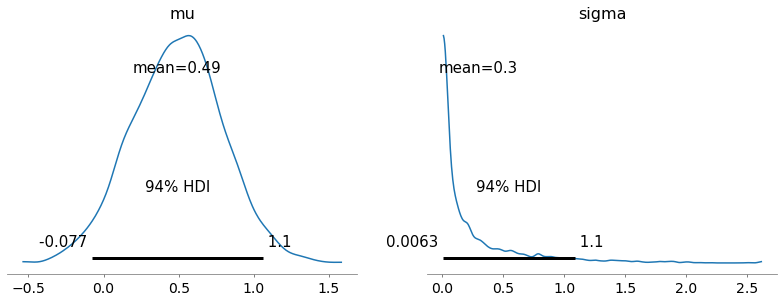

Stime della media di theta:
0.4880105203080992

Deviazione standard di theta:
0.300780204796057


NameError: name 'sampler_stats' is not defined

In [8]:
n=1
reaction_HF=reaction_HF_test[0:n]
U_HF=U_HF_test[0:n]

def custom_operation(x, U_HF):
    return np.log(np.sqrt(2*np.pi)*np.sqrt(np.sqrt(np.mean(np.square(x - U_HF)))))*tt.sum((x - U_HF)**2)/(2*np.sqrt(np.mean(np.square(x - U_HF))))


with pm.Model() as model:
    
    
    mu = pm.Normal('mu', mu=0.5, sd=0.3)
    sigma = pm.HalfNormal('sigma', sd=1)

    # Definisci la variabile di input per il modello Keras
    input_var = pm.Data('input_var', reaction_HF)

    # Converti il tensor Theano in un array NumPy
    numpy_data = input_var.get_value().astype(np.float32)
    print(numpy_data)
    # Passa i dati a Keras e ottieni le previsioni
    keras_predictions = keras_predict(numpy_data)

    # Utilizza i dati Keras nelle operazioni Theano
    nn_potential = custom_operation(keras_predictions, U_HF)

    # Definisci la likelihood
    obs = pm.Normal('obs', mu=nn_potential, sd=sigma, observed=0)

    # Esegui l'inferenza MCMC
    trace = pm.sample(2000, tune=1000, cores=1, random_seed=42)
    # #    # Definisci la variabile di input per il modello Keras
    # # input_var = pm.Data('input_var', reaction_HF)

    # # # Converti il tensor Theano in un array NumPy
    # # numpy_data = input_var.get_value().astype(np.float32)

    # # # Passa i dati a Keras e ottieni le previsioni
    # # keras_predictions = keras_predict(numpy_data)

    # # # Utilizza i dati Keras nelle operazioni Theano
    # # nn_potential = pm.Potential('nn_potential', custom_operation(keras_predictions, U_HF))

    # # # Definisci la likelihood (gestita dal potenziale)
    # # #likelihood = pm.Normal('likelihood', mu=0.5, sd=0.5, observed=0)

    # # # Esegui l'inferenza MCMC
    # # trace = pm.sample(2000, tune=1000, cores=1, step=pm.Metropolis())
    
    
    
    # # input_var = pm.Data('input_var', reaction_HF)

    # # nn_potential = pm.Potential('nn_potential', custom_operation(keras_predict(input_var), U_HF))

    # # likelihood = pm.Normal('likelihood', mu=0.5, sd=0.5, observed=0)
    
    # # trace = pm.sample(2000, tune=1000, cores=1,step=pm.Metropolis())
    # Definisci la likelihood
 #   likelihood = pm.Normal('likelihood', mu=0, sd=1, observed=0)  # La likelihood è gestita dal potenziale

#     # Likelihood basato sui dati osservati
#     likelihood= pm.Normal('likelihood', mu=approx_model_output, sd=pm.HalfNormal('sigma', sd=1), observed=data_true)

#     # Likelihood basato sui dati corretti
#     #likelihood_true = pm.Normal('likelihood_true', mu=approx_model_output, sd=pm.HalfNormal('sigma', sd=1), observed=data_true)

#     # Campionamento MCMC
#     trace = pm.sample(2000, tune=1000, cores=1,step=pm.Metropolis())

# # Analisi dei risultati
print(pm.summary(trace).round(2))
pm.traceplot(trace)
# Estrai la traccia dei campioni per la variabile theta
theta_samples = trace['mu']

# Calcola la stima della media e la deviazione standard per ogni parametro
estimated_theta_mean = theta_samples.mean(axis=0)
estimated_theta_std = theta_samples.std(axis=0)

pm.plot_posterior(trace)
plt.show()

# Stampa le stime
print("Stime della media di theta:")
print(estimated_theta_mean)
print("\nDeviazione standard di theta:")
print(estimated_theta_std)

# Recupera le statistiche del sampler
#sampler_stats = trace.get_sampler_stats("metropolis")

# Estrai il numero di acceptance e rejection
acceptance_rates = sampler_stats[:, 0]  # Colonna 0: acceptance
rejection_rates = 1 - acceptance_rates
pm.autocorrplot(trace)

ppc = pm.sample_posterior_predictive(trace, samples=500, model=model)
# Plot acceptance e rejection
plt.plot(acceptance_rates, label="Acceptance Rate")
plt.plot(rejection_rates, label="Rejection Rate")
plt.xlabel("Iteration")
plt.ylabel("Rate")
plt.legend()
plt.show()